# 26 — Integrated Gradients vs SHAP Attribution Comparison (U-ED-LSTM Helpdesk)

Computes attributions for the same prefixes using both methods and compares:
- **Aggregate**: mean |attribution| per feature, with Spearman/Pearson correlation
- **Per-case**: top-1 match rate and top-3 overlap
- **Correlation matrix**: per-feature correlation between IG and SHAP across samples

In [ ]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent
if str(_current) not in sys.path:
    sys.path.insert(0, str(_current))
if str(_current / 'src') not in sys.path:
    sys.path.insert(0, str(_current / 'src'))

In [ ]:
import random
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.stats import spearmanr, pearsonr

from src.interpretability.config.helpdesk_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

TEST_MODE = True
CONFIG.use_improved = False  # set True for the improved variant
TEST_SAMPLE_SIZE = 30
IG_STEPS = 30
SHAP_SAMPLES = 30
SEED = 42
random.seed(SEED)

TARGET = CONFIG.concept_name
%matplotlib inline

In [ ]:
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(
    model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories)
print(f'Cases: {len(eval_helper.cases)}')

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

Cases: 916


/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OrdinalEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/virtualenvs/XAI-Probabilistic_Suffix_Prediction_U-ED-L-p9C7deWr/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/philippeichhorn/.local/share/v

In [ ]:
all_samples = []
for case_name, full_case in tqdm(eval_helper.cases.items(), desc='Collecting'):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        if prefix_len >= 1:
            all_samples.append({'case_name': case_name, 'prefix_len': prefix_len, 'prefix': prefix})

if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
    print(f'Using {len(samples)} samples (test mode)')
else:
    samples = all_samples
    print(f'Using all {len(samples)} samples')

Collecting:   0%|          | 0/916 [00:00<?, ?it/s]

Using 30 samples (test mode)


## Compute IG and SHAP attributions

In [ ]:
from src.interpretability.attribution.shap_explainer import SequenceSHAP

rows_ig = []
rows_shap = []

# Use SHAP's fast feature-level mode (permutation sampling).
# IG is computed per-step then summed to feature level.
shap_explainer = SequenceSHAP(model, model.data_set_categories)

for sample in tqdm(samples, desc='IG + SHAP'):
    prefix = sample['prefix']
    prefix_len = sample['prefix_len']
    cat_t = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_t = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_t, num_t)

    try:
        # --- IG: per-step, then sum to feature level ---
        attr_ig = tool.compute_attribution_map(
            process=process, prefix_length=prefix_len,
            target=TARGET, target_class='auto',
            method='integrated_gradients', n_steps=IG_STEPS)

        ig_feats = {}
        for feat in attr_ig.feature_names:
            if feat in attr_ig.attributions:
                vals = attr_ig.attributions[feat]
                if hasattr(vals, 'detach'):
                    vals = vals.detach().cpu().numpy()
                ig_feats[feat] = float(np.abs(vals).sum())

        # --- SHAP: fast feature-level mode ---
        shap_vals = shap_explainer.compute(
            prefix=prefix, target_output=TARGET, target_value='auto',
            suffix_step=0, n_samples=SHAP_SAMPLES,
            baseline='zero', feature_level=True)

        shap_feats = {}
        for feat, vals in shap_vals.items():
            if hasattr(vals, 'numpy'):
                vals = vals.numpy()
            shap_feats[feat] = float(np.abs(vals).sum())

        row_base = {'case_name': sample['case_name'], 'prefix_len': prefix_len}
        rows_ig.append({**row_base, **ig_feats})
        rows_shap.append({**row_base, **shap_feats})

    except Exception as e:
        print(f'Error {sample["case_name"]}: {e}')

df_ig = pd.DataFrame(rows_ig).fillna(0)
df_shap = pd.DataFrame(rows_shap).fillna(0)
feature_cols = sorted(df_ig.select_dtypes(include='number').columns.drop('prefix_len', errors='ignore'))
print(f'Computed {len(df_ig)} attribution pairs, {len(feature_cols)} features')

IG + SHAP:   0%|          | 0/50 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 1. Aggregate comparison

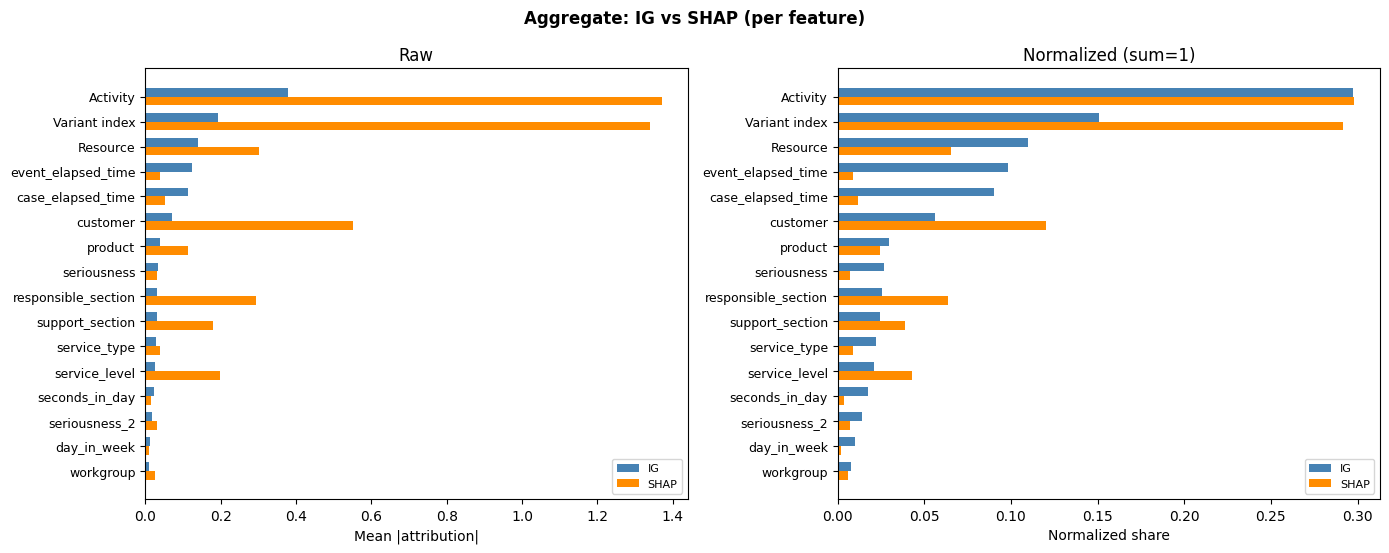

Spearman (16 features): 0.762 (p=0.0006)
Pearson:  0.831 (p=0.0001)


In [ ]:
ig_numeric = df_ig[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
shap_numeric = df_shap[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

mean_ig = ig_numeric.mean().sort_values(ascending=False)
mean_shap = shap_numeric.mean().reindex(mean_ig.index)

norm_ig = mean_ig / mean_ig.sum()
norm_shap = mean_shap / mean_shap.sum()

fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(feature_cols) * 0.35)))
y = np.arange(len(mean_ig))
h = 0.35

ax = axes[0]
ax.barh(y - h/2, mean_ig.values, h, label='IG', color='steelblue')
ax.barh(y + h/2, mean_shap.values, h, label='SHAP', color='darkorange')
ax.set_yticks(y)
ax.set_yticklabels(mean_ig.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Mean |attribution|')
ax.set_title('Raw')
ax.legend(fontsize=8)

ax = axes[1]
ax.barh(y - h/2, norm_ig.values, h, label='IG', color='steelblue')
ax.barh(y + h/2, norm_shap.values, h, label='SHAP', color='darkorange')
ax.set_yticks(y)
ax.set_yticklabels(mean_ig.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Normalized share')
ax.set_title('Normalized (sum=1)')
ax.legend(fontsize=8)

plt.suptitle('Aggregate: IG vs SHAP (per feature)', fontweight='bold')
plt.tight_layout()
plt.show()

rho, p_rho = spearmanr(norm_ig, norm_shap)
r, p_r = pearsonr(norm_ig, norm_shap)
print(f'Spearman ({len(norm_ig)} features): {rho:.3f} (p={p_rho:.4f})')
print(f'Pearson:  {r:.3f} (p={p_r:.4f})')

## 2. Per-case top-1 and top-3 overlap

Top-1 match:   14/30 = 46.7%
Top-3 overlap: 53.3% average


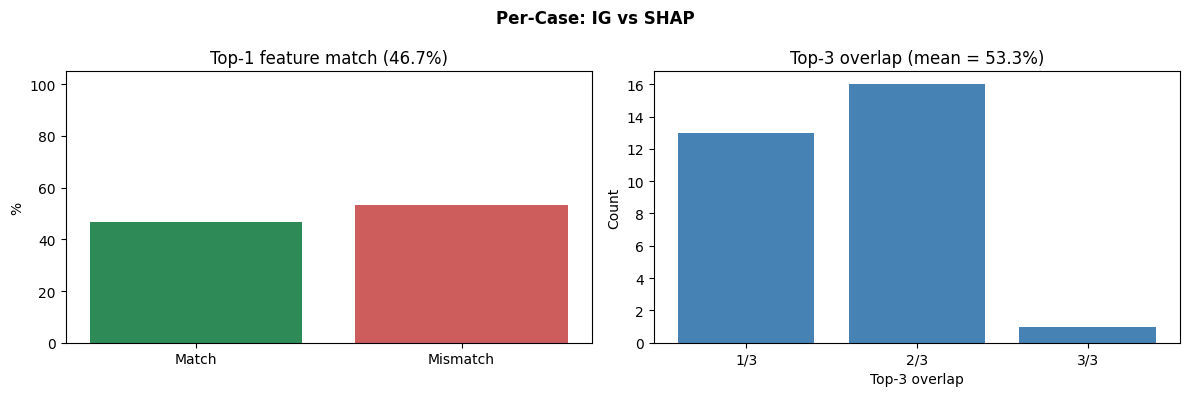

In [ ]:
n = len(df_ig)
top1_match = 0
top3_overlaps = []

for i in range(n):
    ig_vals = ig_numeric.iloc[i]
    shap_vals = shap_numeric.iloc[i]

    if ig_vals.idxmax() == shap_vals.idxmax():
        top1_match += 1

    top3_ig = set(ig_vals.nlargest(3).index)
    top3_shap = set(shap_vals.nlargest(3).index)
    top3_overlaps.append(len(top3_ig & top3_shap) / 3)

top1_pct = top1_match / n * 100
top3_mean = np.mean(top3_overlaps) * 100

print(f'Top-1 match:   {top1_match}/{n} = {top1_pct:.1f}%')
print(f'Top-3 overlap: {top3_mean:.1f}% average')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.bar(['Match', 'Mismatch'], [top1_pct, 100 - top1_pct], color=['seagreen', 'indianred'])
ax.set_ylabel('%')
ax.set_title(f'Top-1 feature match ({top1_pct:.1f}%)')
ax.set_ylim(0, 105)

ax = axes[1]
overlap_counts = pd.Series(top3_overlaps).value_counts().sort_index()
labels = {0.0: '0/3', 1/3: '1/3', 2/3: '2/3', 1.0: '3/3'}
ax.bar([labels.get(k, f'{k:.2f}') for k in overlap_counts.index],
       overlap_counts.values, color='steelblue')
ax.set_xlabel('Top-3 overlap')
ax.set_ylabel('Count')
ax.set_title(f'Top-3 overlap (mean = {top3_mean:.1f}%)')

plt.suptitle('Per-Case: IG vs SHAP', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Per-feature correlation matrix

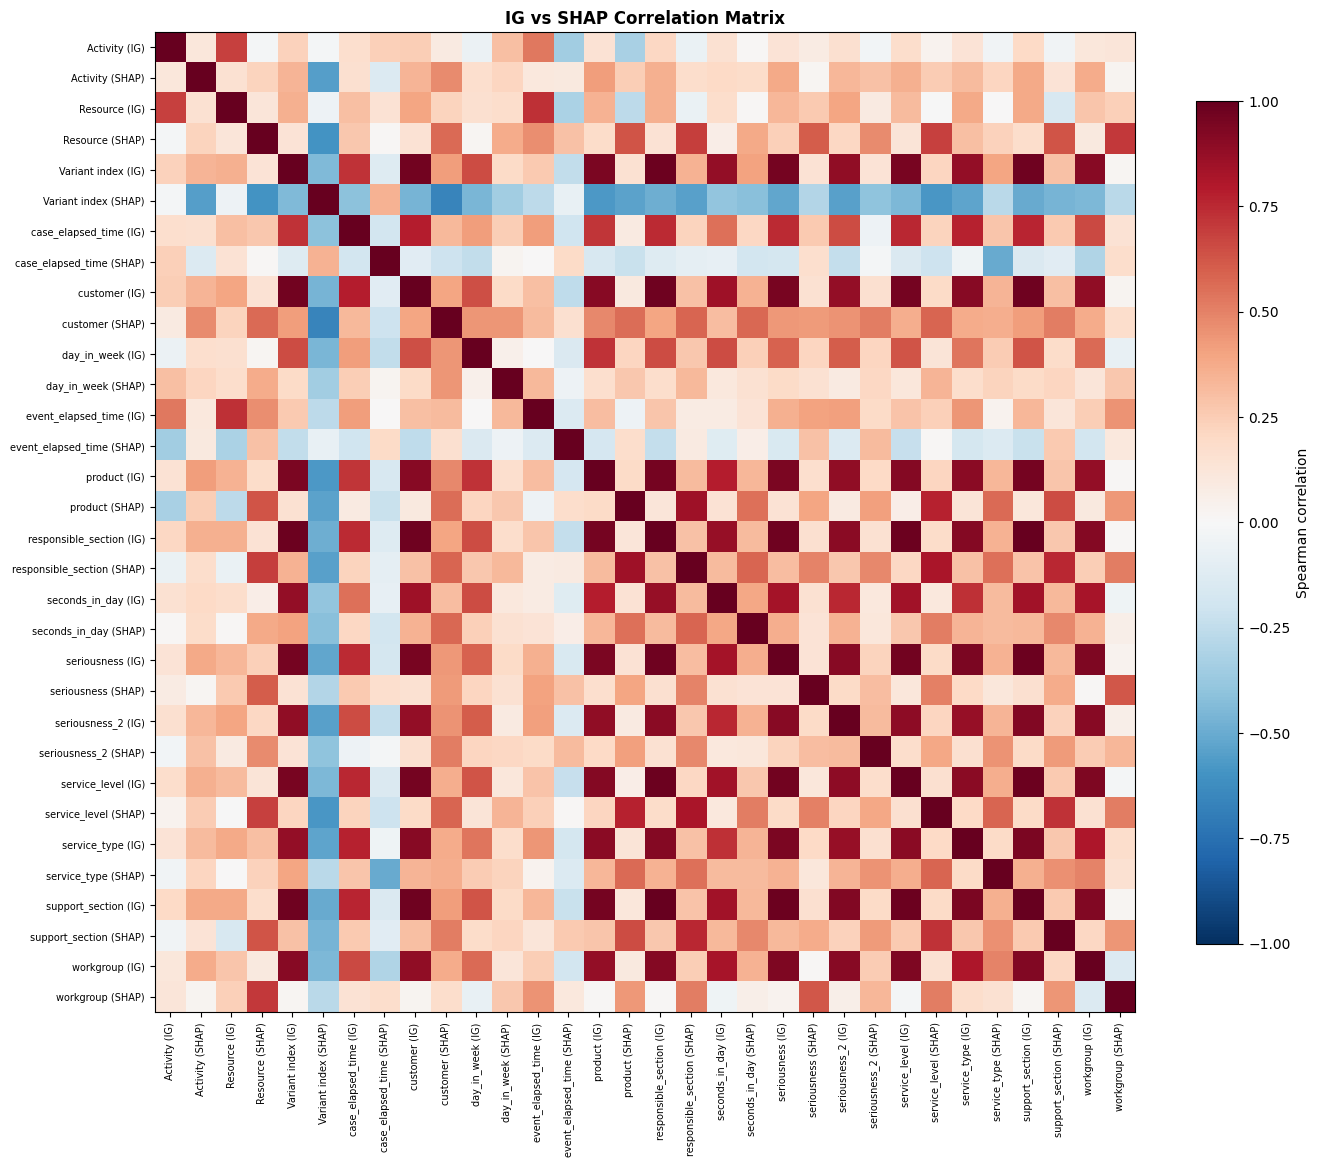

Per-feature cross-method Spearman correlation:
--------------------------------------------------
  Activity                      : 0.110
  Resource                      : 0.121
  Variant index                 : -0.438
  case_elapsed_time             : -0.185
  customer                      : 0.395
  day_in_week                   : 0.048
  event_elapsed_time            : -0.138
  product                       : 0.194
  responsible_section           : 0.295
  seconds_in_day                : 0.383
  seriousness                   : 0.135
  seriousness_2                 : 0.317
  service_level                 : 0.163
  service_type                  : 0.192
  support_section               : 0.264
  workgroup                     : -0.139


In [ ]:
# Correlation matrix directly from feature-level data
combined = pd.DataFrame()
for feat in feature_cols:
    combined[f'{feat} (IG)'] = ig_numeric[feat]
    combined[f'{feat} (SHAP)'] = shap_numeric[feat]

corr = combined.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='equal')
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)
plt.colorbar(im, ax=ax, label='Spearman correlation', shrink=0.8)
ax.set_title('IG vs SHAP Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

print('Per-feature cross-method Spearman correlation:')
print('-' * 50)
for feat in feature_cols:
    r = combined[f'{feat} (IG)'].corr(combined[f'{feat} (SHAP)'], method='spearman')
    print(f'  {feat:30s}: {r:.3f}')

## 4. Summary

In [ ]:
print('=' * 60)
print('SUMMARY: Integrated Gradients vs SHAP')
print('=' * 60)
print(f'Samples:               {n}')
print(f'Features:              {len(feature_cols)}')
print(f'Spearman (aggregate):  {rho:.3f}')
print(f'Pearson (aggregate):   {r:.3f}')
print(f'Top-1 match rate:      {top1_pct:.1f}%')
print(f'Top-3 mean overlap:    {top3_mean:.1f}%')
print()
if rho > 0.9 and top1_pct > 70:
    print('IG and SHAP produce very similar attributions.')
elif rho > 0.7 and top3_mean > 60:
    print('IG and SHAP share most important features but differ in emphasis.')
else:
    print('IG and SHAP produce meaningfully different attributions.')

SUMMARY: Integrated Gradients vs SHAP
Samples:               30
Features:              16
Spearman (aggregate):  0.762
Pearson (aggregate):   -0.139
Top-1 match rate:      46.7%
Top-3 mean overlap:    53.3%

IG and SHAP produce meaningfully different attributions.
